In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd

 Starting Q-learning training...
Parameters: α=0.1, γ=0.99, Episodes=5000
Episode:   500 | Avg. Reward (last 100): -357.76 | Epsilon: 0.7788
Episode:  1000 | Avg. Reward (last 100):  -74.26 | Epsilon: 0.6065
Episode:  1500 | Avg. Reward (last 100):  -39.01 | Epsilon: 0.4723
Episode:  2000 | Avg. Reward (last 100):  -20.54 | Epsilon: 0.3678
Episode:  2500 | Avg. Reward (last 100):   -7.55 | Epsilon: 0.2864
Episode:  3000 | Avg. Reward (last 100):   -5.24 | Epsilon: 0.2230
Episode:  3500 | Avg. Reward (last 100):    0.30 | Epsilon: 0.1737
Episode:  4000 | Avg. Reward (last 100):    1.70 | Epsilon: 0.1353
Episode:  4500 | Avg. Reward (last 100):    3.72 | Epsilon: 0.1053
Episode:  5000 | Avg. Reward (last 100):    5.28 | Epsilon: 0.0820
 Training finished.
 Plotting learning curve...


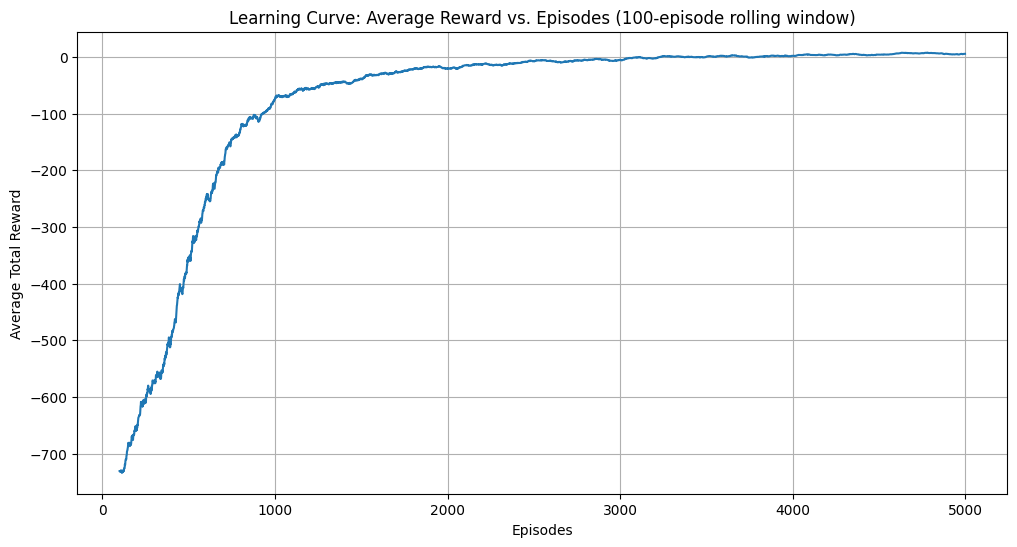


--- Agent Test Run (Post-Training) ---
Initial State: Taxi at (4, 2), Passenger at 0, Dest: 2
Step 1: Action -> N | New State: (3, 2), Pass: 0, Reward: -1
Step 2: Action -> W | New State: (3, 1), Pass: 0, Reward: -1
Step 3: Action -> W | New State: (3, 0), Pass: 0, Reward: -1
Step 4: Action -> N | New State: (2, 0), Pass: 0, Reward: -1
Step 5: Action -> N | New State: (1, 0), Pass: 0, Reward: -1
Step 6: Action -> N | New State: (0, 0), Pass: 0, Reward: -1
Step 7: Action -> Pickup | New State: (0, 0), Pass: 4, Reward: -1
Step 8: Action -> S | New State: (1, 0), Pass: 4, Reward: -1
Step 9: Action -> S | New State: (2, 0), Pass: 4, Reward: -1
Step 10: Action -> S | New State: (3, 0), Pass: 4, Reward: -1
Step 11: Action -> S | New State: (4, 0), Pass: 4, Reward: -1
Step 12: Action -> Drop | New State: (4, 0), Pass: 4, Reward: 20
🎉 Successful dropoff! Total reward: 9


In [2]:
### 1. SETUP: HYPERPARAMETERS AND ENVIRONMENT CONSTANTS

# --- Hyperparameters ---
# Tuned values:
LEARNING_RATE = 0.1       # (α) How much we update Q-values from new info
DISCOUNT_FACTOR = 0.99    # (γ) How much we value future rewards
N_EPISODES = 5000         # Total training episodes

# Epsilon-greedy strategy parameters
EPSILON_START = 1.0       # 100% exploration at the start
EPSILON_MIN = 0.01        # Minimum exploration rate
EPSILON_DECAY = 0.9995    # Decay rate per episode

# --- Environment Constants ---
GRID_ROWS = 5
GRID_COLS = 5

# Passenger locations/destinations (0:A, 1:B, 2:C, 3:D)
# We map these to grid coordinates
LOCATIONS = {
    0: (0, 0),  # A
    1: (0, 4),  # B
    2: (4, 0),  # C
    3: (4, 4)   # D
}

# State space components
N_PASS_LOCS = 5  # 4 locations (0-3) + 1 "in taxi" (4)
N_DESTS = 4      # 4 destinations (0-3)

# Total states = 5 * 5 * 5 * 4 = 500
N_STATES = GRID_ROWS * GRID_COLS * N_PASS_LOCS * N_DESTS

# Action space (0:N, 1:S, 2:E, 3:W, 4:Pickup, 5:Drop)
N_ACTIONS = 6

# Reward structure
R_STEP = -1         # Cost for each move
R_ILLEGAL = -10     # Penalty for illegal pickup/dropoff
R_SUCCESS = 20      # Reward for successful dropoff

# Initialize the Q-table with zeros
# Shape: (500 states, 6 actions)
q_table = np.zeros((N_STATES, N_ACTIONS))


### 2. ENVIRONMENT FUNCTIONS

def encode_state(row, col, pass_loc, dest):
    """Encodes the state tuple (row, col, pass_loc, dest) into a single integer."""
    # Formula: r * (5*5*4) + c * (5*4) + p * (4) + d
    idx = row * (GRID_COLS * N_PASS_LOCS * N_DESTS)
    idx += col * (N_PASS_LOCS * N_DESTS)
    idx += pass_loc * (N_DESTS)
    idx += dest
    return idx

def reset_environment():
    """Resets the environment for a new episode."""
    # Random taxi position
    row = random.randint(0, GRID_ROWS - 1)
    col = random.randint(0, GRID_COLS - 1)
    
    # Random passenger pickup location (0-3)
    pass_loc = random.randint(0, N_DESTS - 1)
    
    # Random passenger destination (0-3), ensuring it's not the same as pickup
    dest = random.randint(0, N_DESTS - 1)
    while dest == pass_loc:
        dest = random.randint(0, N_DESTS - 1)
        
    # Passenger state is their pickup location index (0-3)
    # The "in taxi" state (4) is handled by the 'step' function
    return (row, col, pass_loc, dest)

def step(state, action):
    """Simulates one step in the environment."""
    row, col, pass_loc, dest = state
    
    reward = R_STEP  # Default reward for any action (cost of time/fuel)
    done = False

    # --- 1. Process Movement Actions ---
    if action == 0:  # North
        row = max(0, row - 1)
    elif action == 1:  # South
        row = min(GRID_ROWS - 1, row + 1)
    elif action == 2:  # East
        col = min(GRID_COLS - 1, col + 1)
    elif action == 3:  # West
        col = max(0, col - 1)
    
    # --- 2. Process Pickup Action ---
    elif action == 4:  # Pickup
        if pass_loc == 4:  # Passenger already in taxi
            reward = R_ILLEGAL
        elif (row, col) == LOCATIONS[pass_loc]:  # Taxi is at the correct pickup loc
            pass_loc = 4  # Passenger is now "in taxi"
        else:  # Taxi is at wrong location for pickup
            reward = R_ILLEGAL
            
    # --- 3. Process Dropoff Action ---
    elif action == 5:  # Drop
        if pass_loc != 4:  # Passenger is not in the taxi
            reward = R_ILLEGAL
        elif (row, col) == LOCATIONS[dest]:  # Taxi is at the correct destination
            reward = R_SUCCESS
            done = True  # Episode ends successfully
            # In a real scenario, you might reset pass_loc here,
            # but 'done=True' makes it unnecessary.
        else:  # Taxi is at the wrong location for dropoff
            reward = R_ILLEGAL

    next_state = (row, col, pass_loc, dest)
    return next_state, reward, done


### 3. AGENT FUNCTION

def choose_action(state_idx, epsilon):
    """Chooses an action using the Epsilon-Greedy policy."""
    if random.uniform(0, 1) < epsilon:
        # Explore: choose a random action
        return random.randint(0, N_ACTIONS - 1)
    else:
        # Exploit: choose the best action from Q-table
        return np.argmax(q_table[state_idx])


### 4. MAIN TRAINING LOOP

print(" Starting Q-learning training...")
print(f"Parameters: α={LEARNING_RATE}, γ={DISCOUNT_FACTOR}, Episodes={N_EPISODES}")

# List to store the total reward for each episode
episode_rewards = []
epsilon = EPSILON_START

for episode in range(N_EPISODES):
    
    state = reset_environment()
    total_reward = 0
    done = False
    
    # An episode can run for a max of 200 steps to prevent infinite loops
    for step_num in range(200):
        # 1. Encode the current state
        state_idx = encode_state(*state)
        
        # 2. Choose an action (epsilon-greedy)
        action = choose_action(state_idx, epsilon)
        
        # 3. Take the action and observe the outcome
        next_state, reward, done = step(state, action)
        next_state_idx = encode_state(*next_state)
        
        # 4. Update the Q-table (The Q-Learning formula)
        old_q_value = q_table[state_idx, action]
        
        # Find the max Q-value for the next state (greedy part of the update)
        max_next_q = np.max(q_table[next_state_idx])
        
        # Q-learning update rule
        new_q_value = old_q_value + LEARNING_RATE * (
            reward + DISCOUNT_FACTOR * max_next_q - old_q_value
        )
        q_table[state_idx, action] = new_q_value
        
        # 5. Update state and total reward
        state = next_state
        total_reward += reward
        
        # 6. Check if episode is done
        if done:
            break
            
    # --- End of Episode ---
    
    # Record the total reward
    episode_rewards.append(total_reward)
    
    # Decay epsilon
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    # Print progress
    if (episode + 1) % 500 == 0:
        # Calculate average reward over the last 100 episodes for a stable metric
        avg_reward = np.mean(episode_rewards[-100:])
        print(f"Episode: {episode + 1:5d} | Avg. Reward (last 100): {avg_reward:7.2f} | Epsilon: {epsilon:.4f}")

print(" Training finished.")


### 5. PLOT THE LEARNING CURVE

print(" Plotting learning curve...")

# Use a rolling average to smooth the noisy reward data
# A window of 100 episodes is good for visualization
rolling_avg_rewards = pd.Series(episode_rewards).rolling(window=100).mean()

plt.figure(figsize=(12, 6))
plt.plot(rolling_avg_rewards)
plt.title('Learning Curve: Average Reward vs. Episodes (100-episode rolling window)')
plt.xlabel('Episodes')
plt.ylabel('Average Total Reward')
plt.grid(True)
plt.show()

print("\n--- Agent Test Run (Post-Training) ---")
# Let's see the trained agent in action (0% exploration)
state = reset_environment()
print(f"Initial State: Taxi at ({state[0]}, {state[1]}), Passenger at {state[2]}, Dest: {state[3]}")

total_reward = 0
done = False
for step_num in range(50): # Max 50 steps for test
    state_idx = encode_state(*state)
    action = np.argmax(q_table[state_idx]) # Pure exploitation
    
    # Map action index to a readable string
    action_map = {0:"N", 1:"S", 2:"E", 3:"W", 4:"Pickup", 5:"Drop"}
    print(f"Step {step_num+1}: Action -> {action_map[action]}", end=" | ")
    
    state, reward, done = step(state, action)
    total_reward += reward
    
    print(f"New State: ({state[0]}, {state[1]}), Pass: {state[2]}, Reward: {reward}")
    
    if done:
        print(f"🎉 Successful dropoff! Total reward: {total_reward}")
        break
if not done:
    print(f"Agent failed to complete task in 50 steps. Total reward: {total_reward}")

 Starting Q-learning training...
Parameters: α=0.1, γ=0.99, Episodes=5000
Episode:     1 | Avg Reward (last 1): -740.00 | Epsilon: 0.9995
Episode:   500 | Avg Reward (last 100): -333.11 | Epsilon: 0.7788
Episode:  1000 | Avg Reward (last 100): -90.17 | Epsilon: 0.6065
Episode:  1500 | Avg Reward (last 100): -34.91 | Epsilon: 0.4723
Episode:  2000 | Avg Reward (last 100): -16.43 | Epsilon: 0.3678
Episode:  2500 | Avg Reward (last 100):  -9.93 | Epsilon: 0.2864
Episode:  3000 | Avg Reward (last 100):  -3.14 | Epsilon: 0.2230
Episode:  3500 | Avg Reward (last 100):   0.63 | Epsilon: 0.1737
Episode:  4000 | Avg Reward (last 100):   1.57 | Epsilon: 0.1353
Episode:  4500 | Avg Reward (last 100):   4.65 | Epsilon: 0.1053
Episode:  5000 | Avg Reward (last 100):   5.90 | Epsilon: 0.0820
 Training finished.
 Plotting learning curve...


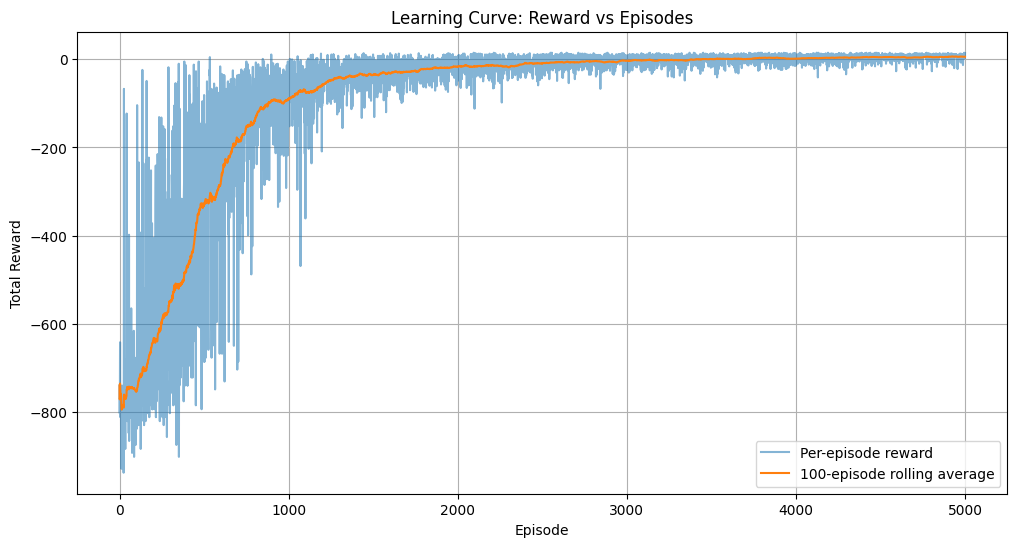


--- Agent Test Run (Post-Training) ---
Initial: Taxi=(3,2), Passenger=3, Dest=1
Step 01: Action -> E       | New: (3,3), Pass=3, Reward=-1
Step 02: Action -> S       | New: (4,3), Pass=3, Reward=-1
Step 03: Action -> E       | New: (4,4), Pass=3, Reward=-1
Step 04: Action -> Pickup  | New: (4,4), Pass=4, Reward=-1
Step 05: Action -> N       | New: (3,4), Pass=4, Reward=-1
Step 06: Action -> N       | New: (2,4), Pass=4, Reward=-1
Step 07: Action -> N       | New: (1,4), Pass=4, Reward=-1
Step 08: Action -> N       | New: (0,4), Pass=4, Reward=-1
Step 09: Action -> Drop    | New: (0,4), Pass=4, Reward=20
🎉 Successful dropoff! Total reward: 12


In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
# ----------------------------

### 1. HYPERPARAMETERS AND ENVIRONMENT CONSTANTS

LEARNING_RATE = 0.1       # α
DISCOUNT_FACTOR = 0.99    # γ
N_EPISODES = 5000

# Epsilon-greedy
EPSILON_START = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.9995

GRID_ROWS = 5
GRID_COLS = 5

# Passenger locations/destinations (0:A, 1:B, 2:C, 3:D)
LOCATIONS = {
    0: (0, 0),  # A
    1: (0, 4),  # B
    2: (4, 0),  # C
    3: (4, 4)   # D
}

N_PASS_LOCS = 5  # 0-3 pickup spots, 4 == in taxi
N_DESTS = 4      # destination indices 0..3

N_STATES = GRID_ROWS * GRID_COLS * N_PASS_LOCS * N_DESTS  # 5*5*5*4 = 500
N_ACTIONS = 6  # N, S, E, W, Pickup, Drop

# Rewards
R_STEP = -1
R_ILLEGAL = -10
R_SUCCESS = 20

# Q-table
q_table = np.zeros((N_STATES, N_ACTIONS), dtype=float)


### 2. ENVIRONMENT HELPERS

def encode_state(row, col, pass_loc, dest):
    """
    Encode (row, col, pass_loc, dest) into a single integer [0..N_STATES-1]
    layout: (((row * GRID_COLS) + col) * N_PASS_LOCS + pass_loc) * N_DESTS + dest
    """
    idx = row * (GRID_COLS * N_PASS_LOCS * N_DESTS)
    idx += col * (N_PASS_LOCS * N_DESTS)
    idx += pass_loc * N_DESTS
    idx += dest
    # Safety check in debug runs:
    assert 0 <= idx < N_STATES, f"Encoded state out of range: {idx}"
    return int(idx)


def reset_environment():
    """Random initial state for each episode."""
    row = random.randint(0, GRID_ROWS - 1)
    col = random.randint(0, GRID_COLS - 1)

    # passenger pickup location (0..3)
    pass_loc = random.randint(0, N_DESTS - 1)

    # destination (not equal to pickup)
    dest = random.randint(0, N_DESTS - 1)
    while dest == pass_loc:
        dest = random.randint(0, N_DESTS - 1)

    return (row, col, pass_loc, dest)


def step(state, action):
    """
    Apply an action. Returns (next_state, reward, done).
    - movement actions always move (but clipped at grid borders) and cost R_STEP
    - pickup/drop handled as per rules; illegal actions are penalized
    """
    row, col, pass_loc, dest = state
    reward = R_STEP
    done = False

    # Movement actions
    if action == 0:  # North
        row = max(0, row - 1)
    elif action == 1:  # South
        row = min(GRID_ROWS - 1, row + 1)
    elif action == 2:  # East
        col = min(GRID_COLS - 1, col + 1)
    elif action == 3:  # West
        col = max(0, col - 1)

    # Pickup
    elif action == 4:
        # If passenger already in taxi -> illegal
        if pass_loc == 4:
            reward = R_ILLEGAL
        else:
            # check taxi at passenger location
            pickup_loc = LOCATIONS[pass_loc]
            if (row, col) == pickup_loc:
                pass_loc = 4  # passenger now in taxi
                # keep default step cost (time), no extra positive reward for pickup
            else:
                reward = R_ILLEGAL

    # Drop
    elif action == 5:
        if pass_loc != 4:
            reward = R_ILLEGAL
        else:
            # check taxi at destination location
            if (row, col) == LOCATIONS[dest]:
                reward = R_SUCCESS
                done = True
            else:
                reward = R_ILLEGAL

    next_state = (row, col, pass_loc, dest)
    return next_state, reward, done


### 3. AGENT: EPSILON-GREEDY WITH TIE-BREAKING

def choose_action(state_idx, epsilon):
    """Epsilon-greedy. When exploiting, break ties randomly among argmax."""
    if random.random() < epsilon:
        return random.randint(0, N_ACTIONS - 1)
    # Exploit: choose random among the best actions to avoid deterministic ties
    q_vals = q_table[state_idx]
    max_q = np.max(q_vals)
    candidates = np.flatnonzero(np.isclose(q_vals, max_q))
    return int(np.random.choice(candidates))


### 4. TRAINING LOOP

print(" Starting Q-learning training...")
print(f"Parameters: α={LEARNING_RATE}, γ={DISCOUNT_FACTOR}, Episodes={N_EPISODES}")

episode_rewards = []
epsilon = EPSILON_START

for episode in range(1, N_EPISODES + 1):
    state = reset_environment()
    total_reward = 0
    done = False

    # limit episode length to avoid infinite loops
    for _step_num in range(200):
        state_idx = encode_state(*state)
        action = choose_action(state_idx, epsilon)

        next_state, reward, done = step(state, action)
        next_state_idx = encode_state(*next_state)

        old_q = q_table[state_idx, action]
        max_next_q = np.max(q_table[next_state_idx])

        # Q-learning update
        q_table[state_idx, action] = old_q + LEARNING_RATE * (
            reward + DISCOUNT_FACTOR * max_next_q - old_q
        )

        state = next_state
        total_reward += reward

        if done:
            break

    episode_rewards.append(total_reward)

    # decay epsilon
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    # logging every 500 episodes
    if episode % 500 == 0 or episode == 1:
        last_n = min(100, len(episode_rewards))
        avg_recent = np.mean(episode_rewards[-last_n:])
        print(f"Episode: {episode:5d} | Avg Reward (last {last_n}): {avg_recent:6.2f} | Epsilon: {epsilon:.4f}")

print(" Training finished.")


### 5. PLOT LEARNING CURVE

print(" Plotting learning curve...")

rewards_series = pd.Series(episode_rewards)
rolling_avg = rewards_series.rolling(window=100, min_periods=1).mean()

plt.figure(figsize=(12, 6))
plt.plot(rewards_series, alpha=0.55, label='Per-episode reward')       # faint per-episode points
plt.plot(rolling_avg, label='100-episode rolling average')              # smoothed curve
plt.title('Learning Curve: Reward vs Episodes')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()


### 6. TEST RUN (pure exploitation)

print("\n--- Agent Test Run (Post-Training) ---")
state = reset_environment()
print(f"Initial: Taxi=({state[0]},{state[1]}), Passenger={state[2]}, Dest={state[3]}")

total_reward = 0
done = False
for step_num in range(50):
    s_idx = encode_state(*state)
    # pure exploitation (choose best action; break ties randomly)
    q_vals = q_table[s_idx]
    max_q = np.max(q_vals)
    action = int(np.random.choice(np.flatnonzero(np.isclose(q_vals, max_q))))

    action_map = {0: "N", 1: "S", 2: "E", 3: "W", 4: "Pickup", 5: "Drop"}
    print(f"Step {step_num+1:02d}: Action -> {action_map[action]:7s}", end=" | ")

    state, reward, done = step(state, action)
    total_reward += reward
    print(f"New: ({state[0]},{state[1]}), Pass={state[2]}, Reward={reward}")

    if done:
        print(f"🎉 Successful dropoff! Total reward: {total_reward}")
        break

if not done:
    print(f"Agent did not complete task within 50 steps. Total reward: {total_reward}")


 Starting Q-learning training...
Parameters: α=0.1, γ=0.99, Episodes=5000
Episode     1 | Avg Reward (last 100): -740.00 | Epsilon: 0.9995
Episode   500 | Avg Reward (last 100): -333.11 | Epsilon: 0.7788
Episode  1000 | Avg Reward (last 100): -90.17 | Epsilon: 0.6065
Episode  1500 | Avg Reward (last 100): -34.91 | Epsilon: 0.4723
Episode  2000 | Avg Reward (last 100): -16.43 | Epsilon: 0.3678
Episode  2500 | Avg Reward (last 100):  -9.93 | Epsilon: 0.2864
Episode  3000 | Avg Reward (last 100):  -3.14 | Epsilon: 0.2230
Episode  3500 | Avg Reward (last 100):   0.63 | Epsilon: 0.1737
Episode  4000 | Avg Reward (last 100):   1.57 | Epsilon: 0.1353
Episode  4500 | Avg Reward (last 100):   4.65 | Epsilon: 0.1053
Episode  5000 | Avg Reward (last 100):   5.90 | Epsilon: 0.0820
 Training finished.


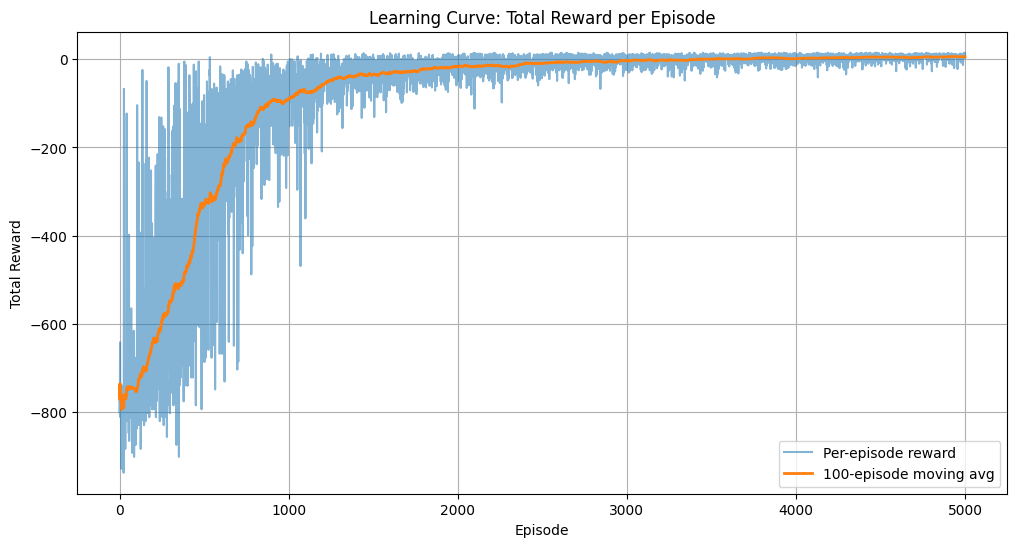

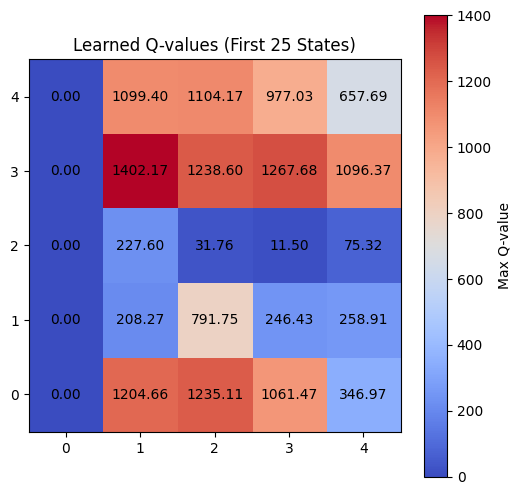


--- 🚖 Agent Test Run (Post-Training) ---
Initial State: Taxi=(3,2), Passenger=3, Destination=1
Step 01: Action → East    | → New: (3,3), Pass=3, Reward=-1
Step 02: Action → South   | → New: (4,3), Pass=3, Reward=-1
Step 03: Action → East    | → New: (4,4), Pass=3, Reward=-1
Step 04: Action → Pickup  | → New: (4,4), Pass=4, Reward=-1
Step 05: Action → North   | → New: (3,4), Pass=4, Reward=-1
Step 06: Action → North   | → New: (2,4), Pass=4, Reward=-1
Step 07: Action → North   | → New: (1,4), Pass=4, Reward=-1
Step 08: Action → North   | → New: (0,4), Pass=4, Reward=-1
Step 09: Action → Drop    | → New: (0,4), Pass=4, Reward=20
🎉 Successful dropoff! Total reward: 12


In [5]:
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
# ----------------------------

### 1️⃣ HYPERPARAMETERS AND ENVIRONMENT CONSTANTS

LEARNING_RATE = 0.1       # α
DISCOUNT_FACTOR = 0.99    # γ
N_EPISODES = 5000

# Epsilon-greedy parameters
EPSILON_START = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.9995

# Environment (5x5 grid world)
GRID_ROWS = 5
GRID_COLS = 5

# Passenger locations/destinations (A, B, C, D)
LOCATIONS = {
    0: (0, 0),  # A
    1: (0, 4),  # B
    2: (4, 0),  # C
    3: (4, 4)   # D
}

# State space:
# row (5) × col (5) × passenger location (5, incl. in taxi) × destination (4)
N_PASS_LOCS = 5  # 0-3 pickup spots, 4 == in taxi
N_DESTS = 4
N_STATES = GRID_ROWS * GRID_COLS * N_PASS_LOCS * N_DESTS  # 5*5*5*4 = 500
N_ACTIONS = 6  # N, S, E, W, Pickup, Drop

# Reward structure
R_STEP = -1
R_ILLEGAL = -10
R_SUCCESS = 20

# Q-table initialization
Q_table = np.zeros((N_STATES, N_ACTIONS), dtype=float)


### 2️⃣ ENVIRONMENT HELPERS

def encode_state(row, col, pass_loc, dest):
    """Encodes (row, col, pass_loc, dest) → single state index."""
    idx = row * (GRID_COLS * N_PASS_LOCS * N_DESTS)
    idx += col * (N_PASS_LOCS * N_DESTS)
    idx += pass_loc * N_DESTS
    idx += dest
    assert 0 <= idx < N_STATES, f"State index out of range: {idx}"
    return int(idx)


def reset_environment():
    """Returns random initial state for each episode."""
    row = random.randint(0, GRID_ROWS - 1)
    col = random.randint(0, GRID_COLS - 1)

    pass_loc = random.randint(0, N_DESTS - 1)
    dest = random.randint(0, N_DESTS - 1)
    while dest == pass_loc:
        dest = random.randint(0, N_DESTS - 1)
    return (row, col, pass_loc, dest)


def step(state, action):
    """
    Performs one environment step.
    Returns: next_state, reward, done
    """
    row, col, pass_loc, dest = state
    reward = R_STEP
    done = False

    # Movement
    if action == 0:  # North
        row = max(0, row - 1)
    elif action == 1:  # South
        row = min(GRID_ROWS - 1, row + 1)
    elif action == 2:  # East
        col = min(GRID_COLS - 1, col + 1)
    elif action == 3:  # West
        col = max(0, col - 1)
    # Pickup
    elif action == 4:
        if pass_loc == 4:
            reward = R_ILLEGAL
        else:
            pickup_loc = LOCATIONS[pass_loc]
            if (row, col) == pickup_loc:
                pass_loc = 4
            else:
                reward = R_ILLEGAL
    # Drop
    elif action == 5:
        if pass_loc != 4:
            reward = R_ILLEGAL
        else:
            if (row, col) == LOCATIONS[dest]:
                reward = R_SUCCESS
                done = True
            else:
                reward = R_ILLEGAL

    next_state = (row, col, pass_loc, dest)
    return next_state, reward, done


### 3 AGENT: EPSILON-GREEDY STRATEGY

def choose_action(state_idx, epsilon):
    """Epsilon-greedy policy with random tie-breaking."""
    if random.random() < epsilon:
        return random.randint(0, N_ACTIONS - 1)
    q_vals = Q_table[state_idx]
    max_q = np.max(q_vals)
    candidates = np.flatnonzero(np.isclose(q_vals, max_q))
    return int(np.random.choice(candidates))


### 4️ TRAINING LOOP

print(" Starting Q-learning training...")
print(f"Parameters: α={LEARNING_RATE}, γ={DISCOUNT_FACTOR}, Episodes={N_EPISODES}")

episode_rewards = []
epsilon = EPSILON_START

for episode in range(1, N_EPISODES + 1):
    state = reset_environment()
    total_reward = 0
    done = False

    for _step_num in range(200):
        state_idx = encode_state(*state)
        action = choose_action(state_idx, epsilon)

        next_state, reward, done = step(state, action)
        next_state_idx = encode_state(*next_state)

        old_q = Q_table[state_idx, action]
        max_next_q = np.max(Q_table[next_state_idx])

        # Q-learning update
        Q_table[state_idx, action] = old_q + LEARNING_RATE * (
            reward + DISCOUNT_FACTOR * max_next_q - old_q
        )

        state = next_state
        total_reward += reward

        if done:
            break

    episode_rewards.append(total_reward)

    # Epsilon decay
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    # Logging every 500 episodes
    if episode % 500 == 0 or episode == 1:
        avg_recent = np.mean(episode_rewards[-100:])
        print(f"Episode {episode:5d} | Avg Reward (last 100): {avg_recent:6.2f} | Epsilon: {epsilon:.4f}")

print(" Training finished.")


### 5️ PLOTTING LEARNING CURVE

rewards_series = pd.Series(episode_rewards)
rolling_avg = rewards_series.rolling(window=100, min_periods=1).mean()

plt.figure(figsize=(12, 6))
plt.plot(rewards_series, alpha=0.55, label='Per-episode reward')
plt.plot(rolling_avg, label='100-episode moving avg', linewidth=2)
plt.title('Learning Curve: Total Reward per Episode')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()


### 6️ POST-TRAINING VISUALIZATION (Top 25 States)

# Show max Q-values for first 25 states in a 5x5 grid
q_values_grid = np.max(Q_table[:25], axis=1).reshape((5, 5))

plt.figure(figsize=(6, 6))
plt.imshow(q_values_grid, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Max Q-value')
plt.title('Learned Q-values (First 25 States)')
plt.xticks(range(5))
plt.yticks(range(5))
plt.gca().invert_yaxis()

# Annotate cell values
for i in range(5):
    for j in range(5):
        plt.text(j, i, f'{q_values_grid[i, j]:.2f}', ha='center', va='center', color='black')

plt.show()


### 7️ TEST RUN (Deterministic Policy)

print("\n--- 🚖 Agent Test Run (Post-Training) ---")
state = reset_environment()
print(f"Initial State: Taxi=({state[0]},{state[1]}), Passenger={state[2]}, Destination={state[3]}")

total_reward = 0
done = False

for step_num in range(50):
    s_idx = encode_state(*state)
    q_vals = Q_table[s_idx]
    max_q = np.max(q_vals)
    action = int(np.random.choice(np.flatnonzero(np.isclose(q_vals, max_q))))

    action_map = {0: "North", 1: "South", 2: "East", 3: "West", 4: "Pickup", 5: "Drop"}
    print(f"Step {step_num+1:02d}: Action → {action_map[action]:7s}", end=" | ")

    state, reward, done = step(state, action)
    total_reward += reward
    print(f"→ New: ({state[0]},{state[1]}), Pass={state[2]}, Reward={reward}")

    if done:
        print(f"🎉 Successful dropoff! Total reward: {total_reward}")
        break

if not done:
    print(f"Agent failed within 50 steps. Total reward: {total_reward}")


 Starting Q-learning training with dynamic α and γ...
Ep    1 | Avg Reward: -740.00 | α=0.799 | γ=0.900 | ε=1.000
Ep  500 | Avg Reward: -218.47 | α=0.485 | γ=0.910 | ε=0.779
Ep 1000 | Avg Reward: -73.17 | α=0.294 | γ=0.920 | ε=0.606
Ep 1500 | Avg Reward: -30.58 | α=0.178 | γ=0.930 | ε=0.472
Ep 2000 | Avg Reward: -16.80 | α=0.108 | γ=0.940 | ε=0.368
Ep 2500 | Avg Reward: -10.64 | α=0.100 | γ=0.950 | ε=0.286
Ep 3000 | Avg Reward:  -5.21 | α=0.100 | γ=0.960 | ε=0.223
Ep 3500 | Avg Reward:  -1.14 | α=0.100 | γ=0.970 | ε=0.174
Ep 4000 | Avg Reward:   3.02 | α=0.100 | γ=0.980 | ε=0.135
Ep 4500 | Avg Reward:   4.18 | α=0.100 | γ=0.990 | ε=0.105
Ep 5000 | Avg Reward:   6.34 | α=0.100 | γ=0.990 | ε=0.082
Ep 5500 | Avg Reward:   6.05 | α=0.100 | γ=0.990 | ε=0.064
Ep 6000 | Avg Reward:   8.09 | α=0.100 | γ=0.990 | ε=0.050
 Training completed!


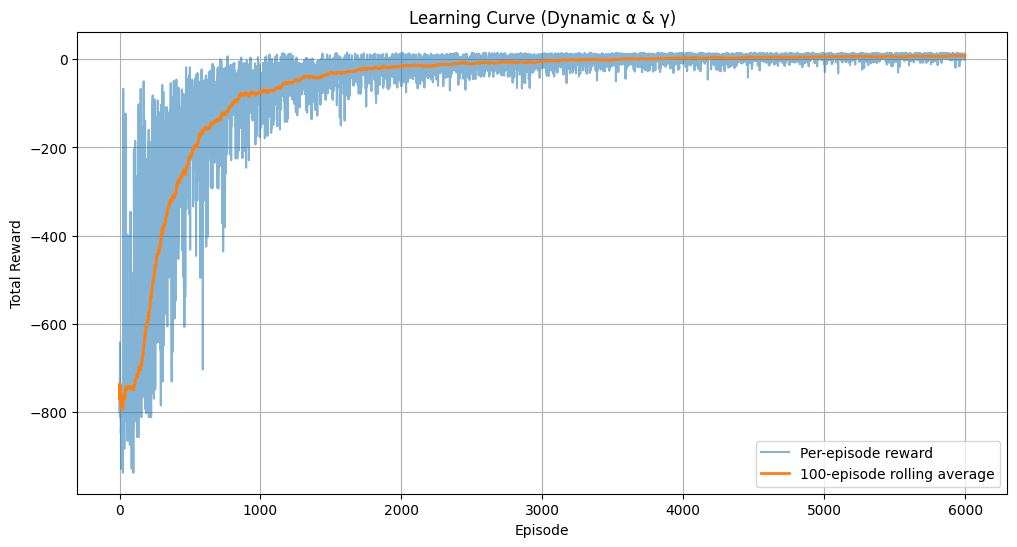


---  Test Run After Training ---
Initial: Taxi=(4,4), Passenger=2, Dest=1
Step 01: Action -> W       | New: (4,3), Pass=2, Reward=-1
Step 02: Action -> W       | New: (4,2), Pass=2, Reward=-1
Step 03: Action -> W       | New: (4,1), Pass=2, Reward=-1
Step 04: Action -> W       | New: (4,0), Pass=2, Reward=-1
Step 05: Action -> Pickup  | New: (4,0), Pass=4, Reward=-1
Step 06: Action -> N       | New: (3,0), Pass=4, Reward=-1
Step 07: Action -> N       | New: (2,0), Pass=4, Reward=-1
Step 08: Action -> E       | New: (2,1), Pass=4, Reward=-1
Step 09: Action -> N       | New: (1,1), Pass=4, Reward=-1
Step 10: Action -> E       | New: (1,2), Pass=4, Reward=-1
Step 11: Action -> N       | New: (0,2), Pass=4, Reward=-1
Step 12: Action -> E       | New: (0,3), Pass=4, Reward=-1
Step 13: Action -> E       | New: (0,4), Pass=4, Reward=-1
Step 14: Action -> Drop    | New: (0,4), Pass=4, Reward=20
🎉 Successful dropoff! Total reward: 7


In [7]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt

# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ----------------------------
### 1. HYPERPARAMETERS AND ENVIRONMENT CONSTANTS

# Base hyperparameters
INITIAL_LEARNING_RATE = 0.8     # Start higher to learn fast initially
MIN_LEARNING_RATE = 0.1         # Lower limit for stability
LEARNING_DECAY = 0.999          # Gradual decay of α per episode

INITIAL_DISCOUNT_FACTOR = 0.90  # Start with slightly lower γ
MAX_DISCOUNT_FACTOR = 0.99      # Gradually increase for long-term reward
DISCOUNT_GROWTH = 0.00002       # Increase γ per episode until max

N_EPISODES = 6000               # Increased episodes for better convergence

# Epsilon-greedy parameters
EPSILON_START = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.9995

GRID_ROWS = 5
GRID_COLS = 5

# Passenger locations/destinations (0:A, 1:B, 2:C, 3:D)
LOCATIONS = {
    0: (0, 0),  # A
    1: (0, 4),  # B
    2: (4, 0),  # C
    3: (4, 4)   # D
}

N_PASS_LOCS = 5  # 0-3 pickup spots, 4 == in taxi
N_DESTS = 4      # destination indices 0..3

N_STATES = GRID_ROWS * GRID_COLS * N_PASS_LOCS * N_DESTS  # 5*5*5*4 = 500
N_ACTIONS = 6  # N, S, E, W, Pickup, Drop

# Rewards
R_STEP = -1
R_ILLEGAL = -10
R_SUCCESS = 20

# Initialize Q-table
q_table = np.zeros((N_STATES, N_ACTIONS), dtype=float)

# ----------------------------
### 2. ENVIRONMENT HELPERS

def encode_state(row, col, pass_loc, dest):
    """Encodes (row, col, pass_loc, dest) into a single integer index."""
    idx = row * (GRID_COLS * N_PASS_LOCS * N_DESTS)
    idx += col * (N_PASS_LOCS * N_DESTS)
    idx += pass_loc * N_DESTS
    idx += dest
    assert 0 <= idx < N_STATES
    return int(idx)


def reset_environment():
    """Random initial environment state."""
    row = random.randint(0, GRID_ROWS - 1)
    col = random.randint(0, GRID_COLS - 1)
    pass_loc = random.randint(0, N_DESTS - 1)
    dest = random.randint(0, N_DESTS - 1)
    while dest == pass_loc:
        dest = random.randint(0, N_DESTS - 1)
    return (row, col, pass_loc, dest)


def step(state, action):
    """Simulates environment dynamics and returns (next_state, reward, done)."""
    row, col, pass_loc, dest = state
    reward = R_STEP
    done = False

    if action == 0:  # North
        row = max(0, row - 1)
    elif action == 1:  # South
        row = min(GRID_ROWS - 1, row + 1)
    elif action == 2:  # East
        col = min(GRID_COLS - 1, col + 1)
    elif action == 3:  # West
        col = max(0, col - 1)
    elif action == 4:  # Pickup
        if pass_loc == 4:
            reward = R_ILLEGAL
        else:
            if (row, col) == LOCATIONS[pass_loc]:
                pass_loc = 4
            else:
                reward = R_ILLEGAL
    elif action == 5:  # Drop
        if pass_loc != 4:
            reward = R_ILLEGAL
        else:
            if (row, col) == LOCATIONS[dest]:
                reward = R_SUCCESS
                done = True
            else:
                reward = R_ILLEGAL

    next_state = (row, col, pass_loc, dest)
    return next_state, reward, done

# ----------------------------
### 3. AGENT POLICY: EPSILON-GREEDY

def choose_action(state_idx, epsilon):
    """Epsilon-greedy action selection with random tie-breaking."""
    if random.random() < epsilon:
        return random.randint(0, N_ACTIONS - 1)
    q_vals = q_table[state_idx]
    max_q = np.max(q_vals)
    candidates = np.flatnonzero(np.isclose(q_vals, max_q))
    return int(np.random.choice(candidates))

# ----------------------------
### 4. TRAINING LOOP WITH DYNAMIC α AND γ

print(" Starting Q-learning training with dynamic α and γ...")
episode_rewards = []
epsilon = EPSILON_START
learning_rate = INITIAL_LEARNING_RATE
discount_factor = INITIAL_DISCOUNT_FACTOR

for episode in range(1, N_EPISODES + 1):
    state = reset_environment()
    total_reward = 0
    done = False

    for _ in range(200):  # step limit
        state_idx = encode_state(*state)
        action = choose_action(state_idx, epsilon)
        next_state, reward, done = step(state, action)
        next_state_idx = encode_state(*next_state)

        old_q = q_table[state_idx, action]
        max_next_q = np.max(q_table[next_state_idx])

        # Q-learning update with dynamic α and γ
        q_table[state_idx, action] = old_q + learning_rate * (
            reward + discount_factor * max_next_q - old_q
        )

        state = next_state
        total_reward += reward
        if done:
            break

    episode_rewards.append(total_reward)

    # Update α and γ adaptively
    learning_rate = max(MIN_LEARNING_RATE, learning_rate * LEARNING_DECAY)
    discount_factor = min(MAX_DISCOUNT_FACTOR, discount_factor + DISCOUNT_GROWTH)

    # Decay ε
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    # Log progress
    if episode % 500 == 0 or episode == 1:
        avg_recent = np.mean(episode_rewards[-100:])
        print(f"Ep {episode:4d} | Avg Reward: {avg_recent:6.2f} | "
              f"α={learning_rate:.3f} | γ={discount_factor:.3f} | ε={epsilon:.3f}")

print(" Training completed!")

# ----------------------------
### 5. PLOT LEARNING CURVE

rewards_series = pd.Series(episode_rewards)
rolling_avg = rewards_series.rolling(window=100, min_periods=1).mean()

plt.figure(figsize=(12, 6))
plt.plot(rewards_series, alpha=0.55, label='Per-episode reward')
plt.plot(rolling_avg, label='100-episode rolling average', linewidth=2)
plt.title('Learning Curve (Dynamic α & γ)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
### 6. TEST RUN (Pure Exploitation)

print("\n---  Test Run After Training ---")
state = reset_environment()
print(f"Initial: Taxi=({state[0]},{state[1]}), Passenger={state[2]}, Dest={state[3]}")

total_reward = 0
done = False
for step_num in range(50):
    s_idx = encode_state(*state)
    q_vals = q_table[s_idx]
    max_q = np.max(q_vals)
    action = int(np.random.choice(np.flatnonzero(np.isclose(q_vals, max_q))))

    action_map = {0: "N", 1: "S", 2: "E", 3: "W", 4: "Pickup", 5: "Drop"}
    print(f"Step {step_num+1:02d}: Action -> {action_map[action]:7s}", end=" | ")

    state, reward, done = step(state, action)
    total_reward += reward
    print(f"New: ({state[0]},{state[1]}), Pass={state[2]}, Reward={reward}")

    if done:
        print(f"🎉 Successful dropoff! Total reward: {total_reward}")
        break

if not done:
    print(f" Agent did not complete task within 50 steps. Total reward: {total_reward}")


 Starting Q-learning training with dynamic α and γ...

Episode:    1 | Avg Reward (last 100): -740.00 | α=0.799 | γ=0.900 | ε=1.000
Episode:  500 | Avg Reward (last 100): -218.47 | α=0.485 | γ=0.910 | ε=0.779
Episode: 1000 | Avg Reward (last 100): -73.17 | α=0.294 | γ=0.920 | ε=0.606
Episode: 1500 | Avg Reward (last 100): -30.58 | α=0.178 | γ=0.930 | ε=0.472
Episode: 2000 | Avg Reward (last 100): -16.80 | α=0.108 | γ=0.940 | ε=0.368
Episode: 2500 | Avg Reward (last 100): -10.64 | α=0.100 | γ=0.950 | ε=0.286
Episode: 3000 | Avg Reward (last 100):  -5.21 | α=0.100 | γ=0.960 | ε=0.223
Episode: 3500 | Avg Reward (last 100):  -1.14 | α=0.100 | γ=0.970 | ε=0.174
Episode: 4000 | Avg Reward (last 100):   3.02 | α=0.100 | γ=0.980 | ε=0.135
Episode: 4500 | Avg Reward (last 100):   4.18 | α=0.100 | γ=0.990 | ε=0.105
Episode: 5000 | Avg Reward (last 100):   6.34 | α=0.100 | γ=0.990 | ε=0.082
Episode: 5500 | Avg Reward (last 100):   6.05 | α=0.100 | γ=0.990 | ε=0.064
Episode: 6000 | Avg Reward (las

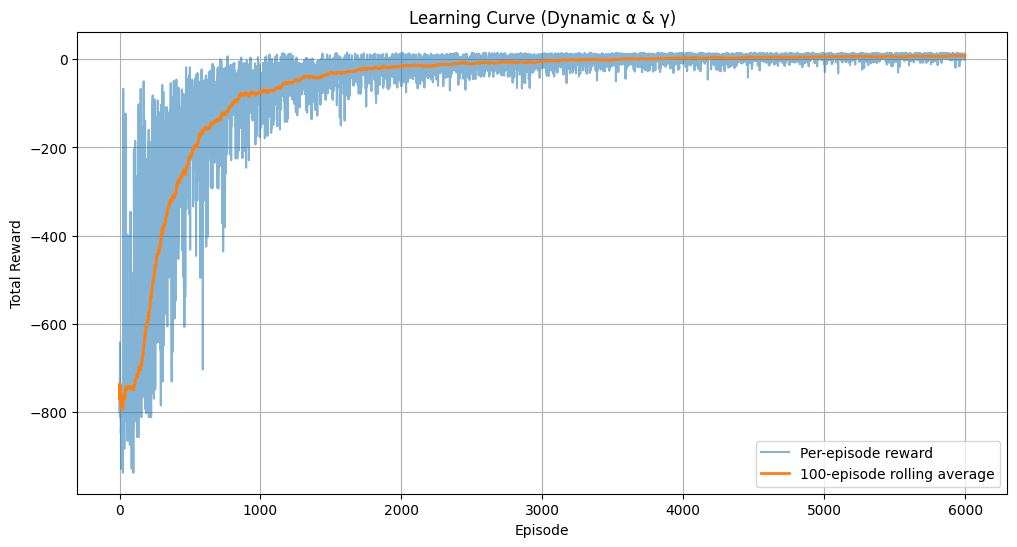

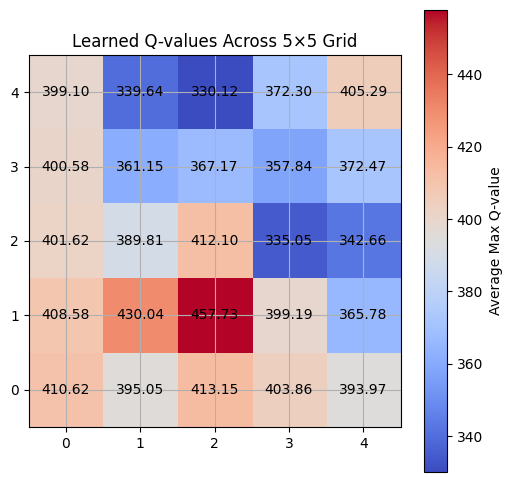

---  Test Run After Training ---
Initial: Taxi=(4,4), Passenger=2, Dest=1
Step 01: Action -> W       | New: (4,3), Pass=2, Reward=-1
Step 02: Action -> W       | New: (4,2), Pass=2, Reward=-1
Step 03: Action -> W       | New: (4,1), Pass=2, Reward=-1
Step 04: Action -> W       | New: (4,0), Pass=2, Reward=-1
Step 05: Action -> Pickup  | New: (4,0), Pass=4, Reward=-1
Step 06: Action -> N       | New: (3,0), Pass=4, Reward=-1
Step 07: Action -> N       | New: (2,0), Pass=4, Reward=-1
Step 08: Action -> E       | New: (2,1), Pass=4, Reward=-1
Step 09: Action -> N       | New: (1,1), Pass=4, Reward=-1
Step 10: Action -> E       | New: (1,2), Pass=4, Reward=-1
Step 11: Action -> N       | New: (0,2), Pass=4, Reward=-1
Step 12: Action -> E       | New: (0,3), Pass=4, Reward=-1
Step 13: Action -> E       | New: (0,4), Pass=4, Reward=-1
Step 14: Action -> Drop    | New: (0,4), Pass=4, Reward=20
 Successful dropoff! Total reward: 7

 Final Learned Q-table (first 30 rows):
[[   0.      0.      0

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

INITIAL_LEARNING_RATE = 0.8      # start high (fast learning)
MIN_LEARNING_RATE = 0.1          # end low (stable updates)
LEARNING_DECAY = 0.999           # decay per episode

INITIAL_DISCOUNT_FACTOR = 0.90   # start short-term focused
MAX_DISCOUNT_FACTOR = 0.99       # end long-term focused
DISCOUNT_GROWTH = 0.00002        # increase per episode

N_EPISODES = 6000                # training episodes

# Epsilon-Greedy Exploration
EPSILON_START = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.9995

GRID_ROWS = 5
GRID_COLS = 5

# Passenger pickup and destination locations (A, B, C, D)
LOCATIONS = {
    0: (0, 0),  # A
    1: (0, 4),  # B
    2: (4, 0),  # C
    3: (4, 4)   # D
}

N_PASS_LOCS = 5   # 0–3 = pickup spots, 4 = in taxi
N_DESTS = 4       # destination IDs 0..3

N_STATES = GRID_ROWS * GRID_COLS * N_PASS_LOCS * N_DESTS  # 5*5*5*4 = 500
N_ACTIONS = 6  # [North, South, East, West, Pickup, Drop]

# Reward system
R_STEP = -1
R_ILLEGAL = -10
R_SUCCESS = 20

# Initialize Q-table
q_table = np.zeros((N_STATES, N_ACTIONS), dtype=float)

def encode_state(row, col, pass_loc, dest):
    """Encode (row, col, pass_loc, dest) into single integer state index."""
    idx = row * (GRID_COLS * N_PASS_LOCS * N_DESTS)
    idx += col * (N_PASS_LOCS * N_DESTS)
    idx += pass_loc * N_DESTS
    idx += dest
    assert 0 <= idx < N_STATES, f"State out of bounds: {idx}"
    return int(idx)


def reset_environment():
    """Initialize a random starting state."""
    row = random.randint(0, GRID_ROWS - 1)
    col = random.randint(0, GRID_COLS - 1)
    pass_loc = random.randint(0, N_DESTS - 1)
    dest = random.randint(0, N_DESTS - 1)
    while dest == pass_loc:
        dest = random.randint(0, N_DESTS - 1)
    return (row, col, pass_loc, dest)


def step(state, action):
    """Simulate one step in the environment."""
    row, col, pass_loc, dest = state
    reward = R_STEP
    done = False

    # Movement actions
    if action == 0:  # North
        row = max(0, row - 1)
    elif action == 1:  # South
        row = min(GRID_ROWS - 1, row + 1)
    elif action == 2:  # East
        col = min(GRID_COLS - 1, col + 1)
    elif action == 3:  # West
        col = max(0, col - 1)

    # Pickup
    elif action == 4:
        if pass_loc == 4:
            reward = R_ILLEGAL
        else:
            if (row, col) == LOCATIONS[pass_loc]:
                pass_loc = 4
            else:
                reward = R_ILLEGAL

    # Drop
    elif action == 5:
        if pass_loc != 4:
            reward = R_ILLEGAL
        else:
            if (row, col) == LOCATIONS[dest]:
                reward = R_SUCCESS
                done = True
            else:
                reward = R_ILLEGAL

    next_state = (row, col, pass_loc, dest)
    return next_state, reward, done

# ============================================================
#   AGENT POLICY: EPSILON-GREEDY
# ============================================================

def choose_action(state_idx, epsilon):
    """Epsilon-greedy action selection with random tie-breaking."""
    if random.random() < epsilon:
        return random.randint(0, N_ACTIONS - 1)
    q_vals = q_table[state_idx]
    max_q = np.max(q_vals)
    candidates = np.flatnonzero(np.isclose(q_vals, max_q))
    return int(np.random.choice(candidates))

# ============================================================
#   TRAINING LOOP (Dynamic α and γ)
# ============================================================

print(" Starting Q-learning training with dynamic α and γ...\n")

episode_rewards = []
epsilon = EPSILON_START
learning_rate = INITIAL_LEARNING_RATE
discount_factor = INITIAL_DISCOUNT_FACTOR

for episode in range(1, N_EPISODES + 1):
    state = reset_environment()
    total_reward = 0
    done = False

    for _ in range(200):  # step limit per episode
        state_idx = encode_state(*state)
        action = choose_action(state_idx, epsilon)

        next_state, reward, done = step(state, action)
        next_state_idx = encode_state(*next_state)

        old_q = q_table[state_idx, action]
        max_next_q = np.max(q_table[next_state_idx])

        # Q-learning update rule
        q_table[state_idx, action] = old_q + learning_rate * (
            reward + discount_factor * max_next_q - old_q
        )

        state = next_state
        total_reward += reward
        if done:
            break

    episode_rewards.append(total_reward)

    # Dynamic α and γ adjustment
    learning_rate = max(MIN_LEARNING_RATE, learning_rate * LEARNING_DECAY)
    discount_factor = min(MAX_DISCOUNT_FACTOR, discount_factor + DISCOUNT_GROWTH)

    # Epsilon decay
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    # Log progress
    if episode % 500 == 0 or episode == 1:
        avg_recent = np.mean(episode_rewards[-100:])
        print(f"Episode: {episode:4d} | Avg Reward (last 100): {avg_recent:6.2f} | "
              f"α={learning_rate:.3f} | γ={discount_factor:.3f} | ε={epsilon:.3f}")

print("\n Training completed!\n")

# ============================================================
#   PLOT LEARNING CURVE
# ============================================================

rewards_series = pd.Series(episode_rewards)
rolling_avg = rewards_series.rolling(window=100, min_periods=1).mean()

plt.figure(figsize=(12, 6))
plt.plot(rewards_series, alpha=0.55, label='Per-episode reward')
plt.plot(rolling_avg, label='100-episode rolling average', linewidth=2)
plt.title('Learning Curve (Dynamic α & γ)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
#   VISUALIZE Q-TABLE (Max Q-values Heatmap)
# ============================================================

# Compute max Q-value per (row, col) grid (aggregating over passenger/destination)
max_q_grid = np.zeros((GRID_ROWS, GRID_COLS))
for row in range(GRID_ROWS):
    for col in range(GRID_COLS):
        # Average max Q over all passenger/destination combinations for this cell
        indices = [encode_state(row, col, p, d) for p in range(N_PASS_LOCS) for d in range(N_DESTS)]
        max_q_grid[row, col] = np.mean([np.max(q_table[idx]) for idx in indices])

plt.figure(figsize=(6, 6))
plt.imshow(max_q_grid, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Average Max Q-value')
plt.title('Learned Q-values Across 5×5 Grid')
plt.xticks(np.arange(GRID_COLS), range(GRID_COLS))
plt.yticks(np.arange(GRID_ROWS), range(GRID_ROWS))
plt.gca().invert_yaxis()
plt.grid(True)

# Annotate Q-values
for i in range(GRID_ROWS):
    for j in range(GRID_COLS):
        plt.text(j, i, f'{max_q_grid[i, j]:.2f}', ha='center', va='center', color='black')

plt.show()

# ============================================================
#   TEST RUN (Post-Training)
# ============================================================

print("---  Test Run After Training ---")
state = reset_environment()
print(f"Initial: Taxi=({state[0]},{state[1]}), Passenger={state[2]}, Dest={state[3]}")

total_reward = 0
done = False
for step_num in range(50):
    s_idx = encode_state(*state)
    q_vals = q_table[s_idx]
    max_q = np.max(q_vals)
    action = int(np.random.choice(np.flatnonzero(np.isclose(q_vals, max_q))))

    action_map = {0: "N", 1: "S", 2: "E", 3: "W", 4: "Pickup", 5: "Drop"}
    print(f"Step {step_num+1:02d}: Action -> {action_map[action]:7s}", end=" | ")

    state, reward, done = step(state, action)
    total_reward += reward
    print(f"New: ({state[0]},{state[1]}), Pass={state[2]}, Reward={reward}")

    if done:
        print(f" Successful dropoff! Total reward: {total_reward}")
        break

if not done:
    print(f" Agent did not complete task within 50 steps. Total reward: {total_reward}")

# ============================================================
# 8️  PRINT FINAL Q-TABLE (Optional)
# ============================================================

np.set_printoptions(precision=2, suppress=True)
print("\n Final Learned Q-table (first 30 rows):")
print(q_table[:30])  # print first 30 for brevity
print(f"\nQ-table shape: {q_table.shape}")
